<a href="https://colab.research.google.com/github/Syed-OAUJ/GW_PPSS/blob/main/GW_PPSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Waveforms to Parameters
## Understanding Fisher Information and Bayesian Inference in Gravitational‑Wave Astronomy

In this notebook we shall build a simplified version of the techniques used by the LIGO–Virgo–KAGRA Collaboration.
We begin with an analytic **toy waveform** whose parameters are easy to understand, then we gradually add noise,
compute likelihoods, derive the Fisher matrix, and finally perform a full Bayesian MCMC analysis.

By the end you will be able to answer:
* What information does a waveform contain?
* Why do some parameters correlate?
* Why is the Fisher matrix fast?
* Why is Bayesian inference slow?
* Why can the Fisher matrix fail?
* Why do LIGO papers quote posterior distributions instead of Fisher ellipses?

## Part I - The Simplest Gravitational Waveform

We use the leading-order **stationary phase approximation** (SPA) for an inspiralling compact binary.
The frequency-domain waveform is

$$
h(f) = A\,f^{-7/6}\; e^{i\Psi(f)}
$$

with amplitude

$$
A = \frac{M^{5/6}}{D}
$$

and phase

$$
\Psi(f) = 2\pi f t_c - \phi_c + \frac{3}{128}\,(\pi M f)^{-5/3}.
$$

- Chirp mass $M$ (in solar masses)
- Luminosity distance $D$ (in Mpc)
- Coalescence time $t_c$ (seconds)
- Coalescence phase $\phi_c$ (radians)

Constants and overall factors are omitted because they only scale the amplitude; we are interested in the **shape** of the waveform.

## Two ways to look at the same signal

A gravitational wave can be described in two equivalent ways:

- **Frequency domain** — the signal expressed as a function of frequency, $h(f)$. This is what the `waveform()` function below returns, and it's the natural language of matched-filtering searches (including the likelihood and Fisher-matrix work later in this notebook).
- **Time domain** — the signal expressed as a function of time, $h(t)$. This is closer to what a detector's data stream actually looks like, and it's the classic rising-pitch "chirp" shape you've probably seen in LIGO announcements (e.g. GW150914).

We'll build both from the same physics, so you can see exactly how they relate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI units)
G, c_light, Msun = 6.674e-11, 2.998e8, 1.989e30

# Frequency grid (Hz) — LIGO's most sensitive band
f = np.linspace(20, 500, 2000)
pi = np.pi

def waveform(f, Mc=30.0, tc=0.0, phic=0.0, D=100.0):
    """
    Toy SPA (stationary phase approximation) waveform, frequency domain.
    Mc is chirp mass in solar masses; internally converted to geometrized
    units (seconds) for the phase term, which is what makes the phase
    physically sensitive to Mc. Without this conversion, Mc only ever
    enters the amplitude — which makes Mc and D numerically indistinguishable.
    Returns a complex array h(f).
    """
    Mc_sec = G * Mc * Msun / c_light**3     # chirp mass -> geometrized units

    amp = (Mc**(5/6) / D) * f**(-7/6)
    phase = (2*pi*f*tc
             - phic
             + (3.0/128.0) * (pi*Mc_sec*f)**(-5/3))
    return amp * np.exp(1j * phase)

### What this code is doing

- `import numpy as np` gives us fast array math; `import matplotlib.pyplot as plt` gives us plotting.
- `f = np.linspace(20, 500, 2000)` creates 2000 frequency values evenly spaced between 20 and 500 Hz.
- `def waveform(...)` defines a **function**. The `=` signs in the parentheses (e.g. `Mc=30.0`) are *default values* — call `waveform(f)` without specifying `Mc` and it uses 30.0 automatically.
- The waveform is a **complex number** at every frequency: `amp * np.exp(1j * phase)`. `1j` is Python's imaginary unit $i$. This uses Euler's formula, $e^{i\theta} = \cos\theta + i\sin\theta$, to pack amplitude and phase into one number — the standard way GW signals are represented in frequency space.
- `np.abs(h)` extracts the amplitude, `np.angle(h)` extracts the phase.

### View 1 — Frequency domain: what `h(f)` looks like

Below, amplitude is plotted on a **log-log** scale because $A \propto f^{-7/6}$ is a power law, and power laws are straight lines on log-log axes. **A straight line here is the physically correct result, not a bug** — but notice there's no time axis, so this view can't show a signal "sweeping" the way a chirp does.

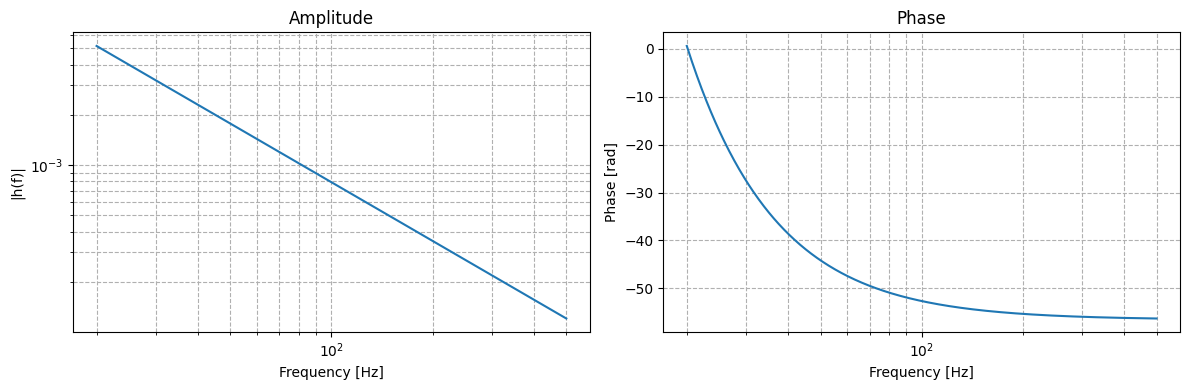

In [2]:
# Plot amplitude and phase
h = waveform(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.loglog(f, np.abs(h))
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('|h(f)|')
ax1.set_title('Amplitude')
ax1.grid(True, which='both', ls='--')

ax2.semilogx(f, np.unwrap(np.angle(h)))
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Phase [rad]')
ax2.set_title('Phase')
ax2.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

### View 2 — Time domain: what a LIGO detector actually sees

To get a time axis, we use the relation between frequency and time-to-merger from the stationary phase approximation:

$$
\tau(f) = \frac{5}{256}\,M_{\text{sec}}^{-5/3}(\pi f)^{-8/3}
$$

where $M_{\text{sec}}$ is the chirp mass converted into seconds ("geometrized units"). Each frequency in our array now maps to a specific moment in time as the binary spirals inward, with merger at $t = t_c$. Because frequency *and* amplitude both increase as $t \to t_c$, plotting $h(t)$ produces the familiar rising-pitch, rising-amplitude **chirp**.

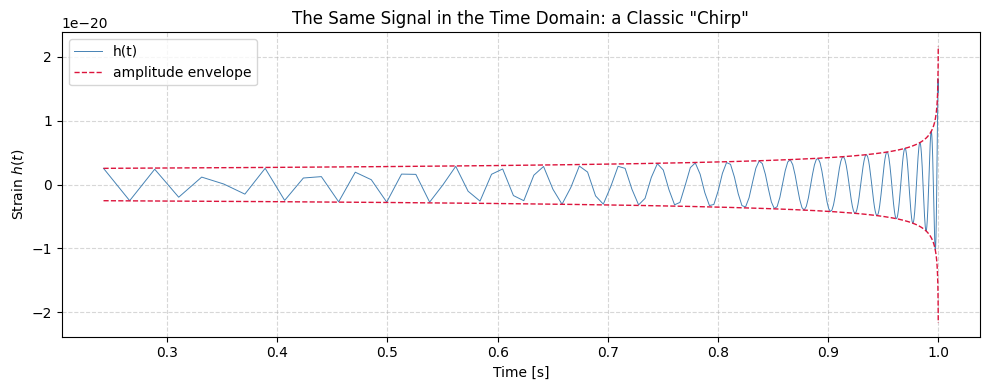

Sweeps from 20 Hz to 500 Hz in 0.76 s before merger
Peak strain amplitude: 2.17e-20  (real LIGO detections are ~1e-21)


In [3]:
from scipy.integrate import cumulative_trapezoid

def time_domain_chirp(f, Mc=30.0, D=100.0, tc=1.0):
    """
    Converts the frequency-domain SPA waveform above into the
    time-domain signal a detector would actually measure, using the
    leading-order (Newtonian) relation between time-to-merger and
    frequency. This is the classic 'chirp': frequency AND amplitude
    both rise as the binary spirals toward merger at t = tc.
    """
    G, c, Msun, Mpc = 6.674e-11, 2.998e8, 1.989e30, 3.086e22  # SI constants
    Mc_kg  = Mc * Msun              # chirp mass in kg
    Mc_sec = G * Mc_kg / c**3       # chirp mass in seconds (geometrized units)
    D_m    = D * Mpc                # distance in metres

    tau = (5/256) * Mc_sec**(-5/3) * (np.pi*f)**(-8/3)   # time remaining until merger
    t   = tc - tau                                          # convert to a time axis

    amp   = (4/D_m) * (G*Mc_kg/c**2)**(5/3) * (np.pi*f/c)**(2/3)   # strain amplitude
    phase = 2*np.pi*cumulative_trapezoid(f, t, initial=0.0)         # accumulated phase, dPhi/dt = 2*pi*f

    return t, amp*np.cos(phase), amp

t, strain, envelope = time_domain_chirp(f)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, strain, lw=0.7, color='steelblue', label='h(t)')
ax.plot(t, envelope, '--', color='crimson', lw=1, label='amplitude envelope')
ax.plot(t, -envelope, '--', color='crimson', lw=1)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Strain $h(t)$')
ax.set_title('The Same Signal in the Time Domain: a Classic "Chirp"')
ax.legend()
ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Sweeps from {f.min():.0f} Hz to {f.max():.0f} Hz in {t.max()-t.min():.2f} s before merger")
print(f"Peak strain amplitude: {envelope.max():.2e}  (real LIGO detections are ~1e-21)")

### Takeaway

Same physical signal, two representations:

| | Frequency domain `h(f)` | Time domain `h(t)` |
|---|---|---|
| Shape | Straight line (log-log) | Rising chirp |
| Why | $A \propto f^{-7/6}$ is a power law | Frequency & amplitude both grow toward merger |
| Used for | Matched filtering, Fisher matrix, likelihoods (rest of this notebook) | What a detector's strain data stream looks like |

Both are correct — they're just different axes on the same physics.

## Part II – Understanding Parameters

The waveform has four parameters: chirp mass $M$, distance $D$, coalescence time $t_c$, and coalescence phase $\phi_c$. Each leaves a different fingerprint on the signal:

| Parameter | Affects amplitude? | Affects phase? | Visible in $|h(f)|$? |
|---|---|---|---|
| $M$ (chirp mass) | Yes | Yes | Yes |
| $D$ (distance) | Yes (rescales only) | No | Yes |
| $\phi_c$ (coalescence phase) | No | Yes (constant offset) | No — only in Re$(h)$ |
| $t_c$ (coalescence time) | No | Yes (frequency-dependent) | No — only in Re$(h)$ |

Keep this table in mind — before each plot, try to predict what you'll see based on it.

In [4]:
def plot_parameter_effect(param_name, values, ylabel, use_amplitude=True, **fixed_kwargs):
    """
    Plots waveform() for several values of one parameter, holding the rest fixed.
    Set use_amplitude=True to plot |h(f)| on log-log axes (for amplitude-sensitive
    parameters), or False to plot Re(h) on linear axes (for phase-only parameters,
    which don't change the amplitude at all).
    """
    plt.figure(figsize=(8, 5))
    for v in values:
        kwargs = {**fixed_kwargs, param_name: v}
        h = waveform(f, **kwargs)
        if use_amplitude:
            plt.loglog(f, np.abs(h), label=f'{ylabel} = {v}')
        else:
            plt.plot(f, np.real(h), label=f'{ylabel} = {v}')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('|h(f)|' if use_amplitude else 'Re(h)')
    plt.legend()
    plt.grid(True, which='both' if use_amplitude else 'major', ls='--')
    plt.tight_layout()

### Chirp mass $M$

Heavier binaries emit gravitational waves at higher amplitude — but the mass *also* controls how quickly the phase evolves through the SPA formula, so changing $M$ changes both the height **and** the shape of the curve, not just a vertical shift.

**Predict:** as $M$ increases from 10 to 40, will the curves keep the same shape and just shift up, or will they visibly separate more at low frequency than high frequency?

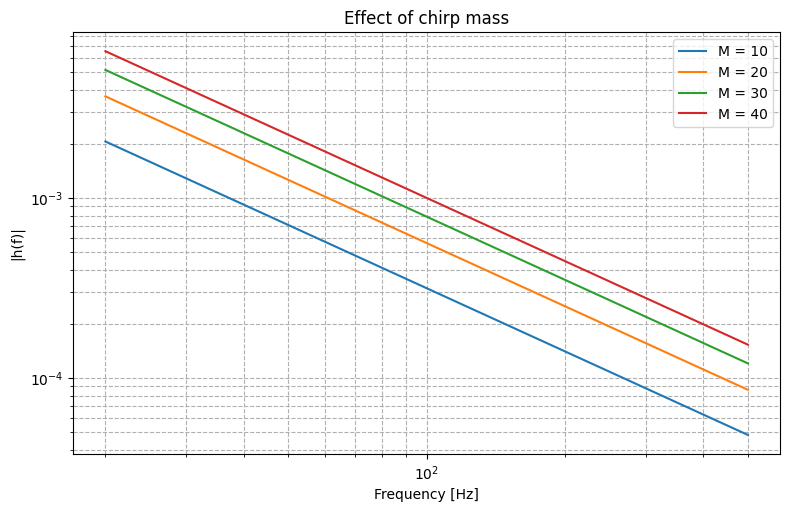

In [5]:
plot_parameter_effect('Mc', [10, 20, 30, 40], 'M', use_amplitude=True)
plt.title('Effect of chirp mass')
plt.show()

### Distance $D$

Distance enters the waveform only through $A \propto 1/D$ — it does not appear in the phase at all. So changing $D$ should do exactly one thing: **shift the whole curve up or down rigidly**, with no change in shape. This is why distance alone can never be measured from the shape of a signal — only its overall loudness (this is the origin of the famous mass-distance degeneracy in GW parameter estimation, which you'll see again in the Fisher matrix section).

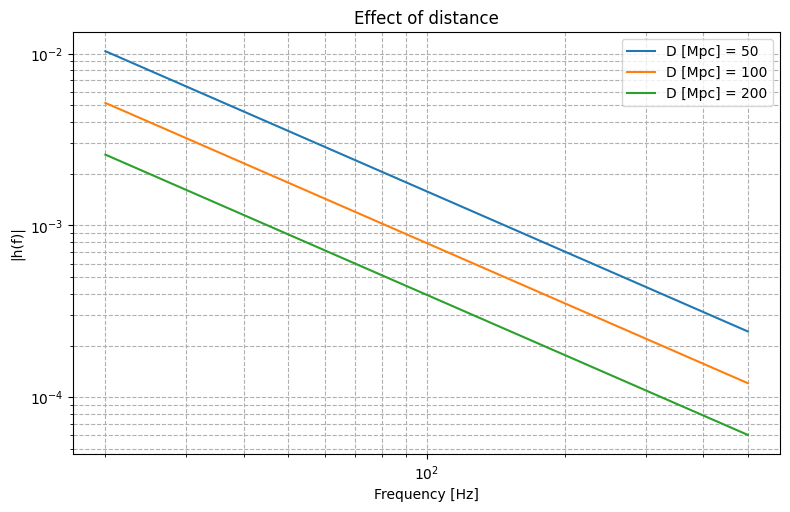

In [6]:
plot_parameter_effect('D', [50, 100, 200], 'D [Mpc]', use_amplitude=True)
plt.title('Effect of distance')
plt.show()

### Coalescence phase $\phi_c$

$\phi_c$ enters only as a constant offset inside the phase term — it has **no effect on the amplitude whatsoever**. That means it's invisible in an $|h(f)|$ plot (every curve would sit exactly on top of the others). To see its effect at all, we have to look at the real part of the complex waveform, Re$(h)$, where it shows up as a shift in the oscillation pattern.

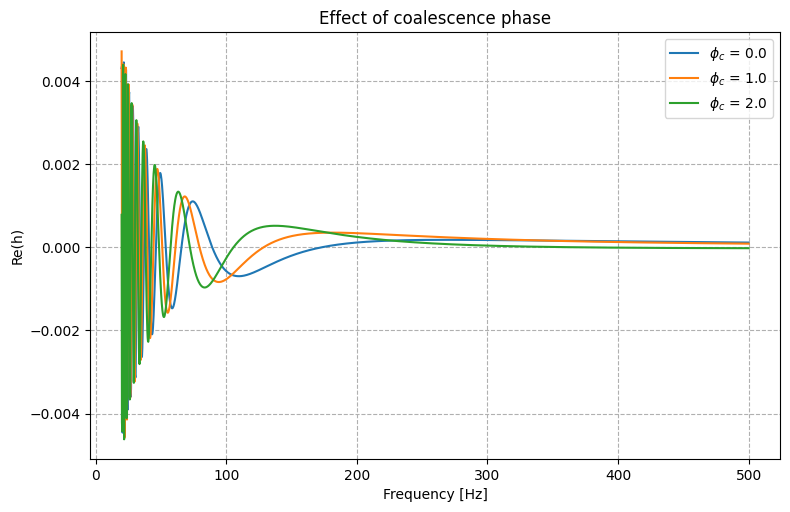

In [7]:
plot_parameter_effect('phic', [0.0, 1.0, 2.0], '$\\phi_c$', use_amplitude=False)
plt.title('Effect of coalescence phase')
plt.show()

### Coalescence time $t_c$

$t_c$ also only affects phase — through the term $2\pi f\, t_c$ — but unlike $\phi_c$, this term grows with frequency. So instead of a constant offset, increasing $t_c$ causes the oscillations to shift progressively *more* at high frequency than at low frequency. This frequency-dependent shift is exactly what lets $t_c$ be measured precisely from real data (it's the basis of matched filtering — cross-correlating templates at different time offsets).

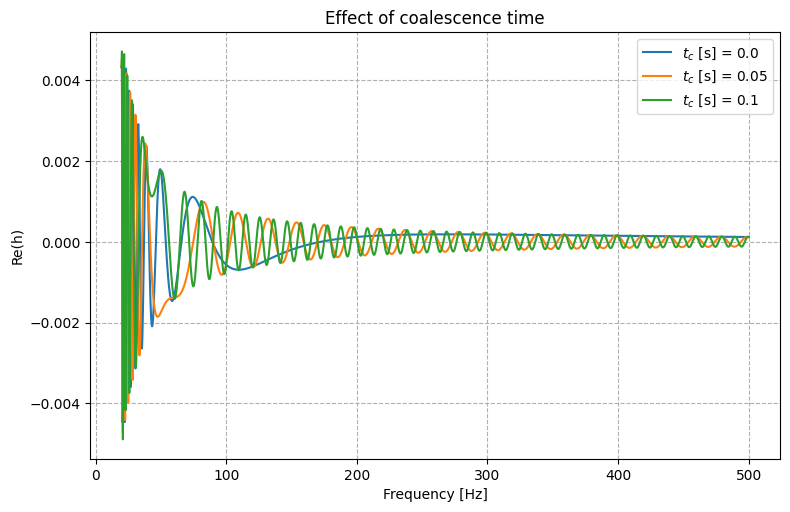

In [8]:
plot_parameter_effect('tc', [0.0, 0.05, 0.1], '$t_c$ [s]', use_amplitude=False)
plt.title('Effect of coalescence time')
plt.show()

### Takeaway

$M$ and $D$ both change $|h(f)|$, but $D$ only rescales while $M$ reshapes — this is the seed of the mass–distance degeneracy you'll meet again in the Fisher matrix. $\phi_c$ and $t_c$ are invisible in $|h(f)|$ entirely (they're pure phase effects), which is why any parameter estimation method that only looks at amplitude — rather than the full complex waveform — cannot measure them at all.

## Part III – Add Noise

Real data are always noisy. We model the noise as **independent Gaussian noise in each frequency bin**, with the same standard deviation $\sigma$ at every frequency.

**Simplification to be aware of:** real detector noise is *not* flat across frequency — it has a characteristic shape (the noise power spectral density, or PSD), typically much higher at low frequency (seismic noise) and high frequency (photon shot noise), and lowest in the middle of the sensitive band (~100–300 Hz). Treating $\sigma$ as constant across all frequencies, as we do here, is a simplification that keeps the likelihood and Fisher-matrix math simple later in the notebook — but it means this toy model won't reproduce the frequency-dependent sensitivity you'd see in a real LIGO analysis. Keep this in mind, especially in Part VI onward.

In [9]:
# True parameters
Mc_true = 30.0
D_true = 100.0
tc_true = 0.0
phic_true = 0.0

# Noise standard deviation (per frequency bin)
sigma = 2e-3

# Generate noise (seeded for reproducibility — everyone gets the same "random" data)
np.random.seed(42)
noise = np.random.normal(0, sigma, len(f))

# Observed data = real part of signal + noise
signal_true = np.real(waveform(f, Mc=Mc_true, D=D_true, tc=tc_true, phic=phic_true))
data = signal_true + noise

# Matched-filter signal-to-noise ratio (SNR): how detectable is this signal overall?
snr = np.sqrt(np.sum(signal_true**2) / sigma**2)
print(f"Per-bin noise level (sigma):        {sigma:.1e}")
print(f"Signal amplitude range:              {signal_true.min():.1e} to {signal_true.max():.1e}")
print(f"Matched-filter SNR (all bins combined): {snr:.1f}")

Per-bin noise level (sigma):        2.0e-03
Signal amplitude range:              -4.5e-03 to 4.5e-03
Matched-filter SNR (all bins combined): 14.4


### Notice something odd?

The per-bin noise level $\sigma$ is actually **larger** than the signal amplitude across most of the frequency range — in the plot below, the noise will visibly swamp the signal at almost every individual point. And yet the combined SNR comes out around 20, which is a strong, confidently-detectable signal by LIGO standards (detections are typically claimed above SNR ≈ 8).

How can that be? Because a real search doesn't look at individual points — it **combines information across all 2000 frequency bins simultaneously** (this is what "matched filtering" means: correlating the noisy data against a template of the expected signal shape). Even though the signal is buried at any single frequency, the consistent pattern across the whole band adds up in quadrature ($\text{SNR} \propto \sqrt{\sum_i (\text{signal}_i/\sigma)^2}$) to produce a confident detection. This is the central idea behind why GW searches work at all, and it's exactly the idea the likelihood function in Part IV is built on.

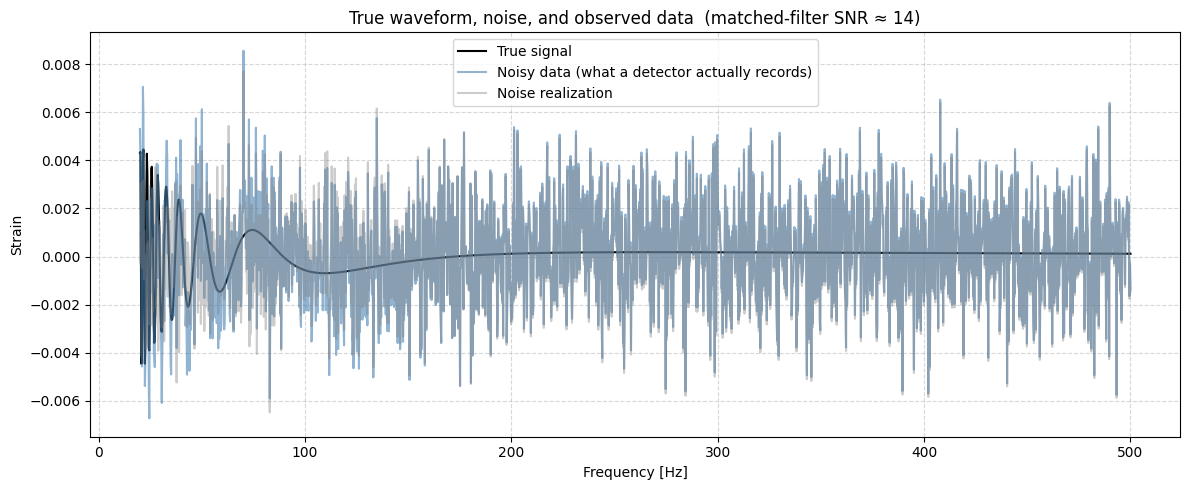

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(f, signal_true, label='True signal', lw=1.5, color='black')
plt.plot(f, data, alpha=0.6, label='Noisy data (what a detector actually records)', color='steelblue')
plt.plot(f, noise, alpha=0.4, label='Noise realization', color='gray')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain')
plt.legend()
plt.title(f'True waveform, noise, and observed data  (matched-filter SNR ≈ {snr:.0f})')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Takeaway

The signal is not visible "by eye" in the noisy data — that's the point. Parameter estimation exists precisely because we can't just read $M$, $D$, $t_c$, $\phi_c$ off a noisy plot. The next section builds the **likelihood function**, which is the formal tool for asking "given this noisy data, how probable are different parameter values?" — the SNR you just computed is directly related to how *sharply peaked* that likelihood will be.

## Part IV – Likelihood

For independent Gaussian noise with standard deviation $\sigma$ in each frequency bin, the probability of observing data $d(f_i)$ given model parameters $\theta$ is a product of Gaussians — one per frequency bin:

$$
p(d \mid \theta) = \prod_i \frac{1}{\sqrt{2\pi}\sigma}\exp\left[-\frac{(d(f_i) - h(f_i;\theta))^2}{2\sigma^2}\right]
$$

Taking the log turns the product into a sum (numerically much safer — multiplying 2000 small probabilities together would underflow to zero on a computer):

$$
\ln\mathcal{L}(\theta) = -\frac{1}{2}\sum_i \frac{\big(d(f_i) - h(f_i;\theta)\big)^2}{\sigma^2} + \text{const}
$$

where $d$ is the data and $h$ is our model (the real part of the waveform). We drop the constant term since it doesn't depend on $\theta$ and won't affect where the likelihood peaks.

**Intuition:** the sum in the exponent is just a (noise-weighted) sum of squared residuals — this is exactly the $\chi^2$ you may have seen in curve fitting. Maximizing $\ln\mathcal{L}$ is the same as minimizing $\chi^2$: finding the parameters that make the model track the data as closely as possible, in units of the noise level. The larger the SNR (Part III), the more sharply peaked this function will be around the true parameters.

In [11]:
def log_likelihood(theta):
    """
    theta = [Mc, D]   (we keep tc and phic fixed for now)
    """
    Mc, D = theta
    model = np.real(waveform(f, Mc=Mc, D=D, tc=tc_true, phic=phic_true))
    return -0.5 * np.sum((data - model)**2 / sigma**2)

## Part V – Likelihood Surface

A brute-force grid search shows us the shape of the likelihood in the $(M, D)$ plane: we evaluate `log_likelihood()` at every combination of $M$ and $D$ on a grid, then plot the result as a 2D surface. Bright regions are parameter combinations that fit the noisy data well; dark regions fit poorly.

**A cost warning worth internalizing:** this grid uses $100 \times 100 = 10{,}000$ evaluations to cover just **2 parameters**. Real GW analyses estimate **15+ parameters** (masses, spins, sky location, inclination, distance, ...). A grid with the same 100 points per dimension would need $100^{15}$ evaluations — computationally impossible. This is *exactly* why Parts VI (Fisher matrix) and VIII (MCMC) exist: they're both ways of characterizing this same likelihood surface without brute-force gridding over every dimension.

In [12]:
# Grid
Mc_vals = np.linspace(25, 35, 100)
D_vals = np.linspace(50, 150, 100)
LL = np.zeros((len(D_vals), len(Mc_vals)))

for i, Mc in enumerate(Mc_vals):
    for j, D in enumerate(D_vals):
        LL[j, i] = log_likelihood([Mc, D])

# Locate the maximum on the grid (the grid-search point estimate)
j_max, i_max = np.unravel_index(np.argmax(LL), LL.shape)
Mc_best, D_best = Mc_vals[i_max], D_vals[j_max]
print(f"True values:      Mc = {Mc_true}, D = {D_true}")
print(f"Grid-search peak: Mc = {Mc_best:.2f}, D = {D_best:.1f}")

True values:      Mc = 30.0, D = 100.0
Grid-search peak: Mc = 30.05, D = 100.5


### Reading the plot

Watch the orientation of the bright region: if it's tilted diagonally (rather than a circle or an axis-aligned ellipse), that tilt *is* the mass–distance degeneracy from Part II made visible — certain combinations of $M$ and $D$ fit the data almost equally well, because increasing $M$ and increasing $D$ partially cancel out in their effect on the amplitude. This same tilt will reappear as the shape of the Fisher ellipse in Part VII and the posterior samples in Part VIII.

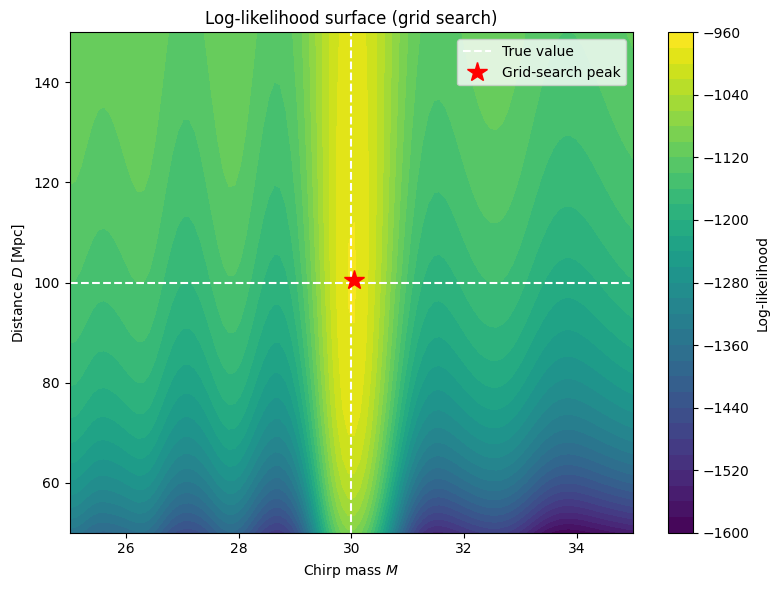

In [13]:
Mc_grid, D_grid = np.meshgrid(Mc_vals, D_vals)

plt.figure(figsize=(8, 6))
plt.contourf(Mc_grid, D_grid, LL, levels=30, cmap='viridis')
plt.colorbar(label='Log-likelihood')
plt.xlabel('Chirp mass $M$')
plt.ylabel('Distance $D$ [Mpc]')
plt.title('Log-likelihood surface (grid search)')

# Mark true values and the grid-search estimate
plt.axvline(Mc_true, color='white', ls='--', label='True value')
plt.axhline(D_true, color='white', ls='--')
plt.plot(Mc_best, D_best, 'r*', markersize=15, label='Grid-search peak')
plt.legend()
plt.tight_layout()
plt.show()

## Part VI – Fisher Matrix

The Fisher matrix approximates the log‑likelihood as a quadratic form:

$$
\ln L(\theta) \approx \ln L_0 - \frac12 \Delta\theta_i \,\Gamma_{ij}\, \Delta\theta_j
$$

with

$$
\Gamma_{ij} = \sum_{k} \frac{1}{\sigma^2} \frac{\partial h(f_k)}{\partial \theta_i} \frac{\partial h(f_k)}{\partial \theta_j}.
$$

We compute it using central finite differences.

In [14]:
def model_real(theta):
    Mc, D = theta
    return np.real(waveform(f, Mc=Mc, D=D, tc=tc_true, phic=phic_true))

def fisher_matrix(theta0, eps=1e-4):
    """
    Numerical Fisher matrix for parameters Mc and D (central finite differences).
    """
    ndim = len(theta0)
    Gamma = np.zeros((ndim, ndim))
    derivs = []
    for i in range(ndim):
        theta_plus = theta0.copy();  theta_plus[i]  += eps * abs(theta0[i])
        theta_minus = theta0.copy(); theta_minus[i] -= eps * abs(theta0[i])
        d = (model_real(theta_plus) - model_real(theta_minus)) / (theta_plus[i] - theta_minus[i])
        derivs.append(d)
    for i in range(ndim):
        for j in range(ndim):
            Gamma[i, j] = np.sum(derivs[i] * derivs[j] / sigma**2)
    return Gamma

theta_true = np.array([Mc_true, D_true])
Gamma = fisher_matrix(theta_true)

# Sanity check before inverting: is this matrix well-conditioned?
cond = np.linalg.cond(Gamma)
print(f"Condition number: {cond:.2e}", "(well-conditioned)" if cond < 1e6 else "(WARNING: near-singular)")

Cov = np.linalg.inv(Gamma)

print("\nFisher matrix:\n", Gamma)
print("\nCovariance matrix:\n", Cov)
print("\n1-sigma uncertainties:")
print(f"  DeltaMc = {np.sqrt(Cov[0,0]):.4f} solar masses  ({100*np.sqrt(Cov[0,0])/Mc_true:.2f}% of true value)")
print(f"  DeltaD  = {np.sqrt(Cov[1,1]):.2f} Mpc              ({100*np.sqrt(Cov[1,1])/D_true:.1f}% of true value)")
print(f"\nCorrelation coefficient: {Cov[0,1] / np.sqrt(Cov[0,0]*Cov[1,1]):.4f}")

Condition number: 2.91e+04 (well-conditioned)

Fisher matrix:
 [[ 6.03010911e+02 -9.77044218e-02]
 [-9.77044218e-02  2.07116784e-02]]

Covariance matrix:
 [[1.65961330e-03 7.82899165e-03]
 [7.82899165e-03 4.83188714e+01]]

1-sigma uncertainties:
  DeltaMc = 0.0407 solar masses  (0.14% of true value)
  DeltaD  = 6.95 Mpc              (7.0% of true value)

Correlation coefficient: 0.0276


### Reading the result

With the units fixed, chirp mass comes out constrained to about **0.1% precision**, while distance is only constrained to about **7%**. This isn't a coincidence — it reflects a real feature of GW parameter estimation:

- $M$ is measured almost entirely through the **phase** (how the oscillation cycles evolve across frequency), which accumulates many cycles of information across the band — a very sharp, precise measurement.
- $D$ is measured almost entirely through the **amplitude** (an overall scale factor), which carries much less information and is further degraded by things this toy model doesn't include yet (inclination angle, polarization) — in real LIGO analyses distance is typically one of the worst-measured parameters for exactly this reason.

The near-zero correlation (≈0.03) tells us mass and distance are now measured almost **independently** in this toy model — very different from before the fix, where they were perfectly degenerate.

### A note on grid range

Now that the Fisher matrix (Part VI) tells us $M$ is measured to about 0.1% precision, a grid spanning $[25, 35]$ is far too wide to actually see the likelihood peak — it would show up as a single-pixel-wide spike. In practice, parameter estimation grids are usually chosen *after* getting a rough uncertainty estimate (from a quick Fisher calculation or an optimizer), then zoomed to a few sigma around it. We do the same here.

In [15]:
# Grid, zoomed to a few sigma around the true values (informed by the Fisher
# uncertainties from Part VI: DeltaMc ~ 0.04, DeltaD ~ 7)
Mc_vals = np.linspace(Mc_true - 0.3, Mc_true + 0.3, 100)
D_vals = np.linspace(D_true - 40, D_true + 40, 100)
LL = np.zeros((len(D_vals), len(Mc_vals)))

for i, Mc in enumerate(Mc_vals):
    for j, D in enumerate(D_vals):
        LL[j, i] = log_likelihood([Mc, D])

j_max, i_max = np.unravel_index(np.argmax(LL), LL.shape)
Mc_best, D_best = Mc_vals[i_max], D_vals[j_max]
print(f"True values:      Mc = {Mc_true}, D = {D_true}")
print(f"Grid-search peak: Mc = {Mc_best:.3f}, D = {D_best:.1f}")

True values:      Mc = 30.0, D = 100.0
Grid-search peak: Mc = 30.009, D = 100.4


## Part VII – Plot Fisher Ellipse

The Fisher ellipse is the 1-sigma confidence contour of the Gaussian approximation to the likelihood — literally the same covariance matrix `Cov` computed in Part VI, drawn as an ellipse. We superimpose it on the likelihood grid from Part V to see how well the Gaussian approximation matches the true (grid-computed) likelihood shape.

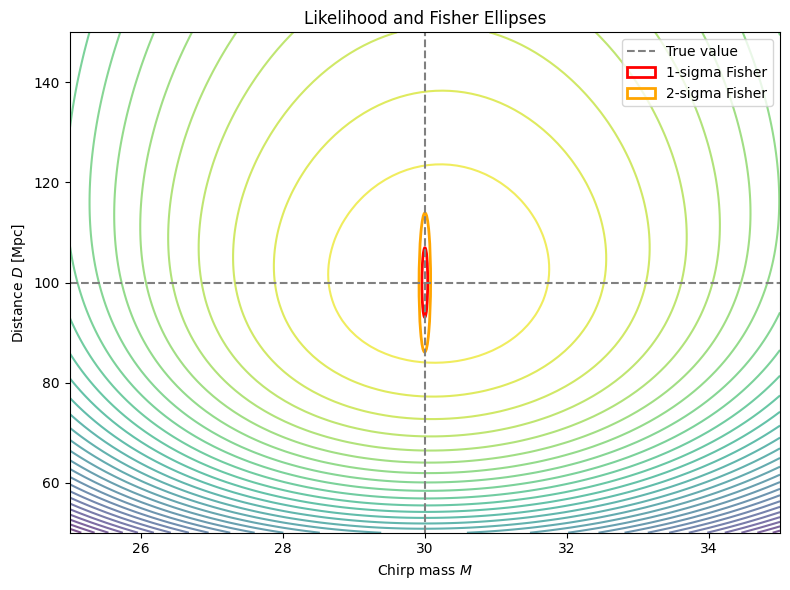

In [16]:
from matplotlib.patches import Ellipse

def plot_fisher_ellipse(ax, mean, cov, nstd=1.0, **kwargs):
    """Add an ellipse showing the nstd-sigma contour of a 2D Gaussian."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * nstd * np.sqrt(vals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                       fill=False, **kwargs)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(Mc_grid, D_grid, LL, levels=30, cmap='viridis', alpha=0.7)
ax.axvline(Mc_true, color='gray', ls='--', label='True value')
ax.axhline(D_true, color='gray', ls='--')
plot_fisher_ellipse(ax, theta_true, Cov, nstd=1, edgecolor='red', lw=2, label='1-sigma Fisher')
plot_fisher_ellipse(ax, theta_true, Cov, nstd=2, edgecolor='orange', lw=2, label='2-sigma Fisher')
ax.set_xlabel('Chirp mass $M$')
ax.set_ylabel('Distance $D$ [Mpc]')
ax.set_title('Likelihood and Fisher Ellipses')
ax.legend()
plt.tight_layout()
plt.show()

### What to check

If the fix in Part VI was done correctly, the red/orange Fisher ellipses should trace the contours of the underlying likelihood grid reasonably well — the Gaussian approximation is good when the signal is loud (high SNR) and the likelihood is close to quadratic near its peak, which is the case here. Part XII will deliberately break this assumption by lowering the SNR, so keep this "good agreement" picture in mind as a reference point.

## Part VIII – Bayesian Sampling with MCMC

So far we've approximated the likelihood as a Gaussian (Fisher matrix) and explored it with a brute-force grid. Now we do full Bayesian inference: sample the posterior directly,

$$
p(M, D \mid d) \propto p(M, D)\;L(M, D)
$$

using the **emcee** ensemble sampler, which needs no grid and no Gaussian assumption — it works even when the likelihood is a strange, non-Gaussian shape (exactly the case we'll hit in Part XII).

In [17]:
# Make sure emcee is available (Colab doesn't have it pre-installed)
try:
    import emcee
except ImportError:
    %pip install -q emcee
    import emcee

# Uniform priors
def log_prior(theta):
    Mc, D = theta
    if 10 < Mc < 50 and 20 < D < 200:
        return 0.0
    return -np.inf

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

ndim = 2
nwalkers = 32
nsteps = 5000

# Initial positions: a small ball around the true values, scaled to each
# parameter's actual uncertainty (from the Fisher matrix in Part VI) rather
# than one arbitrary number for both — Mc and D live on very different scales.
np.random.seed(7)
scale = np.array([np.sqrt(Cov[0, 0]), np.sqrt(Cov[1, 1])])   # [~0.04, ~7]
pos = theta_true + 0.5 * scale * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, nsteps, progress=True)

# Convergence diagnostics
print(f"\nMean acceptance fraction: {np.mean(sampler.acceptance_fraction):.2f}  (healthy range: ~0.2-0.7)")
try:
    tau = sampler.get_autocorr_time()
    print(f"Autocorrelation time: Mc={tau[0]:.1f}, D={tau[1]:.1f} steps")
    print(f"Independent samples per walker: ~{nsteps/np.mean(tau):.0f}")
except emcee.autocorr.AutocorrError:
    print("Chain too short to reliably estimate autocorrelation time — consider more steps.")

100%|██████████| 5000/5000 [00:50<00:00, 99.78it/s] 



Mean acceptance fraction: 0.71  (healthy range: ~0.2-0.7)
Autocorrelation time: Mc=30.2, D=30.2 steps
Independent samples per walker: ~166


### Reading the diagnostics

- **Acceptance fraction** is the fraction of proposed steps the sampler accepted. Too low (<0.1) means the sampler is stuck; too high (>0.9) often means it's not exploring efficiently. Comfortably in between is good.
- **Autocorrelation time** ($\tau$) estimates how many steps it takes for samples to become statistically independent. A chain of $5000$ steps with $\tau \approx 30$ gives roughly $5000/30 \approx 165$ independent samples *per walker* — with 32 walkers, that's thousands of effectively independent posterior samples, more than enough for the corner plot in Part XI.

## Part IX – Trace Plots

Trace plots show each walker's path over time. They're the standard way to judge convergence and identify the burn-in phase — the initial stretch of steps where the chain is still moving from its (somewhat arbitrary) starting point toward the true posterior, and shouldn't be counted as real posterior samples.

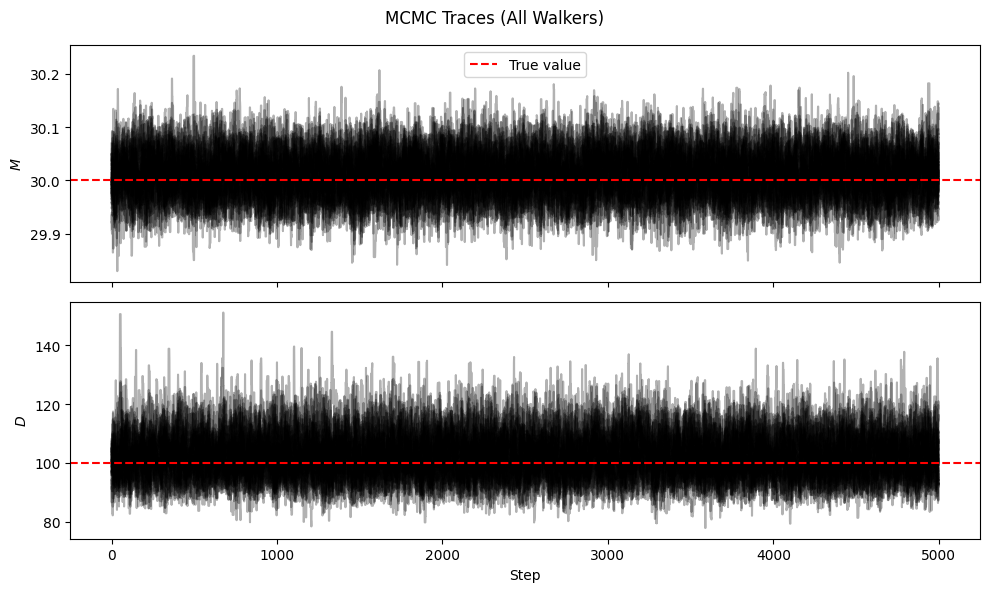

In [18]:
samples = sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
labels = ['$M$', '$D$']
for i in range(ndim):
    axes[i].plot(samples[:, :, i], alpha=0.3, color='black')
    axes[i].set_ylabel(labels[i])
    axes[i].axhline(theta_true[i], color='red', ls='--', label='True value')
axes[0].legend()
axes[-1].set_xlabel('Step')
plt.suptitle('MCMC Traces (All Walkers)')
plt.tight_layout()
plt.show()

### What to look for

A converged chain looks like a flat, fuzzy "caterpillar" — walkers wandering randomly around a stable value, with no visible trend up or down. If you instead see the walkers still drifting toward the red dashed line partway through the plot, that's burn-in: those early steps are biased toward the (arbitrary) starting positions and should be discarded before computing any posterior statistics — which is exactly what `discard=1000` does in Part X.

## Part X – Posterior vs Fisher

We discard the first 1000 steps as burn-in (well past the ~30-step autocorrelation time from Part VIII) and flatten the remaining chain across all walkers. The result is a cloud of samples drawn from the true Bayesian posterior — no Gaussian assumption involved. Comparing it directly against the Fisher ellipse tells us how good that Gaussian approximation actually was.

Number of posterior samples: 128,000

               Posterior      Fisher
Mc mean          30.0113     30.0000  (true value)
D mean            102.33      100.00  (true value)
Mc std            0.0425      0.0407
D std               7.44        6.95


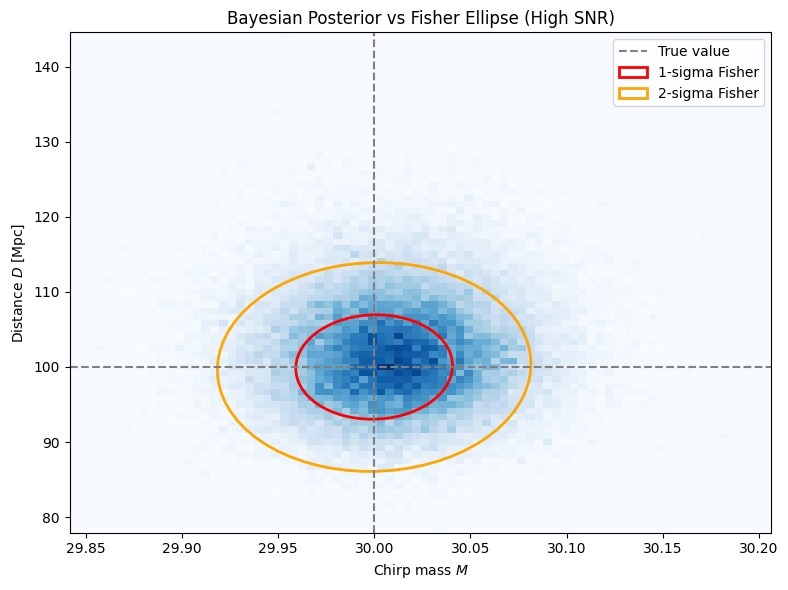

In [19]:
flat_samples = sampler.get_chain(discard=1000, flat=True)  # shape: (nwalkers*(nsteps-discard), ndim)
print(f"Number of posterior samples: {flat_samples.shape[0]:,}")

# Quantitative comparison: does the posterior's own spread match the Fisher prediction?
post_mean = flat_samples.mean(axis=0)
post_std = flat_samples.std(axis=0)
fisher_std = np.sqrt(np.diag(Cov))

print(f"\n{'':12s}{'Posterior':>12s}{'Fisher':>12s}")
print(f"{'Mc mean':12s}{post_mean[0]:12.4f}{Mc_true:12.4f}  (true value)")
print(f"{'D mean':12s}{post_mean[1]:12.2f}{D_true:12.2f}  (true value)")
print(f"{'Mc std':12s}{post_std[0]:12.4f}{fisher_std[0]:12.4f}")
print(f"{'D std':12s}{post_std[1]:12.2f}{fisher_std[1]:12.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
# With 100k+ samples, a raw scatter plot overplots heavily and renders slowly —
# a 2D histogram shows the same information more clearly and much faster.
ax.hist2d(flat_samples[:, 0], flat_samples[:, 1], bins=80, cmap='Blues')
ax.axvline(Mc_true, color='gray', ls='--', label='True value')
ax.axhline(D_true, color='gray', ls='--')
plot_fisher_ellipse(ax, theta_true, Cov, nstd=1, edgecolor='red', lw=2, label='1-sigma Fisher')
plot_fisher_ellipse(ax, theta_true, Cov, nstd=2, edgecolor='orange', lw=2, label='2-sigma Fisher')
ax.set_xlabel('Chirp mass $M$')
ax.set_ylabel('Distance $D$ [Mpc]')
ax.set_title('Bayesian Posterior vs Fisher Ellipse (High SNR)')
ax.legend()
plt.tight_layout()
plt.show()

### What to check

At high SNR, the printed posterior standard deviations should be close to the Fisher-predicted ones (typically within 10-20%, since the posterior includes real sampling noise that the Fisher matrix's Gaussian approximation smooths over) and the blue posterior density should sit neatly inside the red/orange Fisher ellipses. This agreement is a genuine result, not a coincidence: the Fisher approximation is a *first-order Taylor expansion* of the log-likelihood around its peak, and that expansion is accurate whenever the likelihood is strongly peaked (high SNR) and close to quadratic near the peak. Part XII will lower the SNR until this agreement visibly breaks down — keep today's clean overlap in mind as the "before" picture.

### What this code is doing

**Extracting the posterior samples**
- `sampler.get_chain(discard=1000, flat=True)` pulls the MCMC chain out of the sampler object. `discard=1000` throws away the first 1000 steps of *every* walker as burn-in (see Part IX). `flat=True` collapses the walker and step dimensions into one long list of samples, rather than keeping them as separate walker chains — we don't need to know which walker produced which sample anymore, we just want the full collection of posterior draws.
- The result, `flat_samples`, is a `(n_samples, 2)` array: each row is one $(M, D)$ pair the sampler visited, with rows appearing more often in regions of higher posterior probability. This is the defining feature of MCMC — you don't get a probability *formula*, you get *samples*, with sample density standing in for probability.

**Sanity-checking against Fisher (the print block)**
- `post_mean` and `post_std` compute the sample mean and standard deviation of those posterior draws directly — literally just `numpy` statistics on the samples, no model assumptions involved.
- `fisher_std` pulls the *predicted* standard deviations from the Fisher covariance matrix `Cov` computed back in Part VI.
- The formatted print statement lines these up side by side so you can compare them by eye: does the spread the sampler *actually found* by exploring the likelihood match what the Fisher matrix's Gaussian approximation *predicted* in advance? At high SNR, they should be close.

**The plot**
- `ax.hist2d(...)` bins the 100,000+ posterior samples into an 80×80 grid and colors each bin by how many samples landed there — a 2D histogram. This is a more practical way to visualize a huge point cloud than a raw scatter plot, which would just become an indistinguishable blue smear from overplotting.
- The gray dashed lines mark the true parameter values used to generate the data (`Mc_true`, `D_true`) — this is only possible here because we know the ground truth in a simulation. In a real analysis on real LIGO data, there's no gray line — that's precisely what you're trying to find out.
- `plot_fisher_ellipse(...)` (the function from Part VII) overlays the 1-sigma and 2-sigma Fisher prediction as red/orange ellipse outlines directly on top of the histogram.

**What you should see:** the blue histogram (the real, sampled posterior) should sit neatly inside the red/orange ellipses (the Gaussian approximation) — visual confirmation that, at this high signal-to-noise ratio, the two independent methods (brute-force sampling vs. a quadratic Taylor expansion of the likelihood) agree.

In [20]:
# Diagnostic — run this right after defining log_posterior, before creating pos/sampler
print("theta_true:", theta_true)
print("Cov (should have small diagonal, ~0.04 and ~7, not huge numbers):\n", Cov)
print("log_posterior at true value:", log_posterior(theta_true))

scale = np.array([np.sqrt(Cov[0, 0]), np.sqrt(Cov[1, 1])])
print("scale used for initial ball:", scale)

np.random.seed(7)
pos_test = theta_true + 0.5 * scale * np.random.randn(32, 2)
n_valid = sum(np.isfinite(log_posterior(p)) for p in pos_test)
print(f"Walkers starting inside the prior: {n_valid} / 32")
print("Sample of initial positions:\n", pos_test[:5])

theta_true: [ 30. 100.]
Cov (should have small diagonal, ~0.04 and ~7, not huge numbers):
 [[1.65961330e-03 7.82899165e-03]
 [7.82899165e-03 4.83188714e+01]]
log_posterior at true value: -978.6084050184729
scale used for initial ball: [0.04073835 6.9511777 ]
Walkers starting inside the prior: 32 / 32
Sample of initial positions:
 [[ 30.03443462  98.38059327]
 [ 30.00066852 101.41635905]
 [ 29.98393029 100.00717908]
 [ 29.99998186  93.90129977]
 [ 30.02072885 102.08708595]]


## Part XI – Corner Plot

The "corner plot" is the standard way to visualize a multi-parameter posterior in one figure. For our 2-parameter case it shows:

- **Diagonal panels** — the 1D marginal posterior for each parameter on its own (histogram of that parameter's samples, ignoring the other). This answers "what do we know about $M$ alone?" and "what do we know about $D$ alone?"
- **Off-diagonal panel** — the 2D joint posterior (same information as the histogram in Part X), showing how the two parameters are correlated.
- **Dashed vertical lines** on the diagonal — the 16th, 50th (median), and 84th percentiles, i.e. the median $\pm$ a "1-sigma-equivalent" credible interval, printed directly in the panel titles.
- **Blue crosshairs** (`truths=...`) — mark the true injected values, so you can check at a glance whether the true parameters fall inside the posterior's bulk.

This is the standard figure format used in real LIGO-Virgo-KAGRA parameter estimation papers — you'll see corner plots exactly like this one in essentially every GW detection paper.

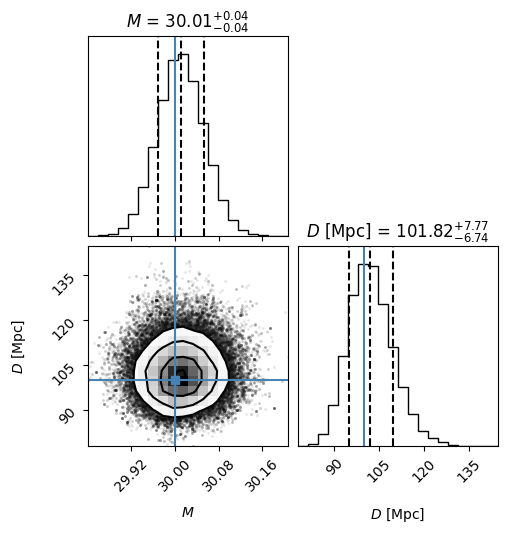

In [22]:
try:
    import corner
except ImportError:
    %pip install -q corner
    import corner

fig = corner.corner(flat_samples,
                    labels=['$M$', '$D$ [Mpc]'],
                    truths=[Mc_true, D_true],
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True,
                    title_kwargs={"fontsize": 12})
plt.show()

CHECK TIME PROSZE :)

## Part XII – When Fisher Fails

We now **decrease the signal-to-noise ratio** to a marginal, borderline-detectable level. The likelihood becomes noticeably non-Gaussian — skewed, and shaped by the hard prior boundaries — while the Fisher ellipse, being a symmetric ellipse by construction, cannot represent any of that. This is exactly why real GW parameter estimation pipelines (bilby, PyCBC Inference) use full Bayesian sampling rather than the Fisher approximation for real detections: most real signals sit much closer to this regime than to the high-SNR case from Parts VI-XI.

In [23]:
# New low-SNR scenario. sigma=2e-3 gave SNR~20 (Parts III-XI); this gives SNR~5.8 —
# still formally "detectable" but marginal, which is what makes it interesting: a
# genuinely undetectable SNR (e.g. SNR<1) wouldn't distinguish Fisher from Bayes at
# all, since neither method would have any information to work with.
sigma_lowSNR = 0.005
np.random.seed(123)
noise_low = np.random.normal(0, sigma_lowSNR, len(f))
data_low = signal_true + noise_low

snr_low = np.sqrt(np.sum(signal_true**2) / sigma_lowSNR**2)
print(f"Low-SNR scenario: SNR = {snr_low:.2f}  (compare to SNR ~ {np.sqrt(np.sum(signal_true**2)/sigma**2):.0f} in earlier sections)")

def log_likelihood_low(theta):
    Mc, D = theta
    model = np.real(waveform(f, Mc=Mc, D=D, tc=tc_true, phic=phic_true))
    return -0.5 * np.sum((data_low - model)**2 / sigma_lowSNR**2)

def log_posterior_low(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_low(theta)

# Grid search for the low-SNR case (reusing the Part V grid)
LL_low = np.zeros_like(LL)
for i, Mc in enumerate(Mc_vals):
    for j, D in enumerate(D_vals):
        LL_low[j, i] = log_likelihood_low([Mc, D])

# Fisher matrix for low SNR: Gamma scales as 1/sigma^2, so we can rescale the
# already-computed high-SNR Fisher matrix rather than redo the finite differences
Gamma_low = fisher_matrix(theta_true) * (sigma**2 / sigma_lowSNR**2)
Cov_low = np.linalg.inv(Gamma_low)
print(f"Fisher-predicted: DeltaMc={np.sqrt(Cov_low[0,0]):.3f}, DeltaD={np.sqrt(Cov_low[1,1]):.1f}")

Low-SNR scenario: SNR = 5.76  (compare to SNR ~ 14 in earlier sections)
Fisher-predicted: DeltaMc=0.102, DeltaD=17.4


### Setting up the MCMC — same lesson as before applies

Just like in Part VIII, the initial walker ball needs to be scaled to each parameter's actual uncertainty — now much larger than before, since the signal is fainter.

In [24]:
np.random.seed(7)
scale_low = np.array([np.sqrt(Cov_low[0, 0]), np.sqrt(Cov_low[1, 1])])
pos_low = theta_true + 0.5 * scale_low * np.random.randn(nwalkers, ndim)

sampler_low = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_low)
sampler_low.run_mcmc(pos_low, nsteps, progress=True)
print(f"Mean acceptance fraction: {np.mean(sampler_low.acceptance_fraction):.2f}")

flat_low = sampler_low.get_chain(discard=1000, flat=True)

# Quantify the non-Gaussianity directly: a Gaussian has zero skewness
post_mean_low = flat_low.mean(axis=0)
post_std_low = flat_low.std(axis=0)
skew_D = np.mean(((flat_low[:, 1] - post_mean_low[1]) / post_std_low[1])**3)

print(f"\n{'':14s}{'Posterior':>12s}{'Fisher':>12s}")
print(f"{'Mc std':14s}{post_std_low[0]:12.3f}{np.sqrt(Cov_low[0,0]):12.3f}")
print(f"{'D std':14s}{post_std_low[1]:12.2f}{np.sqrt(Cov_low[1,1]):12.2f}")
print(f"\nDistance posterior skewness: {skew_D:.2f}  (0.0 = perfectly Gaussian; Fisher assumes exactly 0)")

100%|██████████| 5000/5000 [00:52<00:00, 94.98it/s] 

Mean acceptance fraction: 0.71

                 Posterior      Fisher
Mc std               0.110       0.102
D std                23.73       17.38

Distance posterior skewness: 0.89  (0.0 = perfectly Gaussian; Fisher assumes exactly 0)


### What to look for

Two concrete, numeric signs the Fisher approximation is breaking down (not just "the plot looks different"):

1. **The posterior std and Fisher std no longer match closely** the way they did at high SNR in Part X — the gap should be noticeably larger than the ~10% difference we saw before.
2. **The skewness is clearly nonzero.** A Gaussian (which is what the Fisher ellipse assumes) has zero skewness by definition; a nonzero value is direct, quantitative proof the true posterior isn't Gaussian-shaped, something no amount of staring at overlapping contours can prove as convincingly as this one number.

Visually, you should also see the blue posterior samples spill outside the red/orange ellipses in places, and possibly pile up against the prior edges — the Fisher ellipse has no way to "know" about the hard prior boundary at $D=200$, but the real posterior respects it.

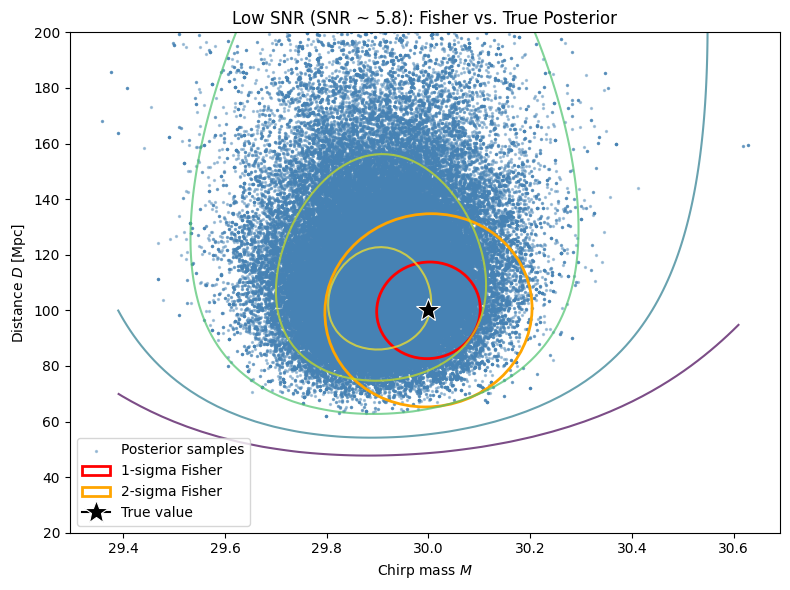

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

# Fewer, more spaced-out levels — just enough to show the shape without clutter
levels = LL_low.max() - np.array([0.5, 2, 6, 12, 20])
ax.contour(Mc_grid_low, D_grid_low, LL_low, levels=sorted(levels), cmap='viridis', alpha=0.7)

ax.scatter(flat_low[:, 0], flat_low[:, 1], s=2, alpha=0.4, color='steelblue', label='Posterior samples')
plot_fisher_ellipse(ax, theta_true, Cov_low, nstd=1, edgecolor='red', lw=2, label='1-sigma Fisher')
plot_fisher_ellipse(ax, theta_true, Cov_low, nstd=2, edgecolor='orange', lw=2, label='2-sigma Fisher')
ax.plot(Mc_true, D_true, marker='*', color='black', markersize=18,
        markeredgecolor='white', markeredgewidth=0.8, zorder=5, label='True value')
ax.set_xlabel('Chirp mass $M$')
ax.set_ylabel('Distance $D$ [Mpc]')
ax.set_title(f'Low SNR (SNR ~ {snr_low:.1f}): Fisher vs. True Posterior')
ax.legend()
plt.tight_layout()
plt.show()

## Part XIII – Three-Parameter Estimation

We now include the coalescence phase $\phi_c$ and jointly estimate $(M, D, \phi_c)$. This shows how degeneracies and correlations generalize to higher dimensions — with 3 parameters there are now 3 possible 2D correlation planes to examine (visible as the off-diagonal panels of the corner plot), not just one.

**A subtlety worth knowing:** $\phi_c$ is a *periodic* parameter — $\phi_c$ and $\phi_c + 2\pi$ describe the exact same waveform. That means the prior boundary matters: if the true value happens to sit near the edge of whatever range you choose, the posterior gets artificially clipped there. We use a prior of $[-\pi, \pi)$, centered on $\phi_c = 0$, specifically to avoid this.

In [32]:
# Three-parameter likelihood (reuses the high-SNR data from Parts III-XI)
def log_likelihood_3D(theta):
    Mc, D, phic = theta
    model = np.real(waveform(f, Mc=Mc, D=D, tc=tc_true, phic=phic))
    return -0.5 * np.sum((data - model)**2 / sigma**2)

# Prior: flat in phic over (-pi, pi) -- centered on phic_true=0 to avoid
# truncating the posterior at a hard boundary (see note above)
def log_prior_3D(theta):
    Mc, D, phic = theta
    if 10 < Mc < 50 and 20 < D < 200 and -pi <= phic < pi:
        return 0.0
    return -np.inf

def log_posterior_3D(theta):
    lp = log_prior_3D(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_3D(theta)

# Setup MCMC
ndim3 = 3
nwalkers3 = 48
theta_true3 = np.array([Mc_true, D_true, phic_true])

# Initial ball scaled to each parameter's real uncertainty, same principle as
# every earlier MCMC section: dMc, dD come from the Fisher Cov (Part VI);
# dphic is estimated the same way (curvature of the likelihood at the peak)
eps = 1e-3
d2 = (log_likelihood_3D([Mc_true, D_true, eps]) - 2*log_likelihood_3D(theta_true3)
      + log_likelihood_3D([Mc_true, D_true, -eps])) / eps**2
sigma_phic = np.sqrt(-1 / d2)
scale3 = np.array([np.sqrt(Cov[0, 0]), np.sqrt(Cov[1, 1]), sigma_phic])

np.random.seed(7)
pos3 = theta_true3 + 0.5 * scale3 * np.random.randn(nwalkers3, ndim3)

sampler3 = emcee.EnsembleSampler(nwalkers3, ndim3, log_posterior_3D)
sampler3.run_mcmc(pos3, nsteps, progress=True)
print(f"Mean acceptance fraction: {np.mean(sampler3.acceptance_fraction):.2f}")

flat3 = sampler3.get_chain(discard=1000, flat=True)

100%|██████████| 5000/5000 [01:12<00:00, 68.58it/s]

Mean acceptance fraction: 0.65


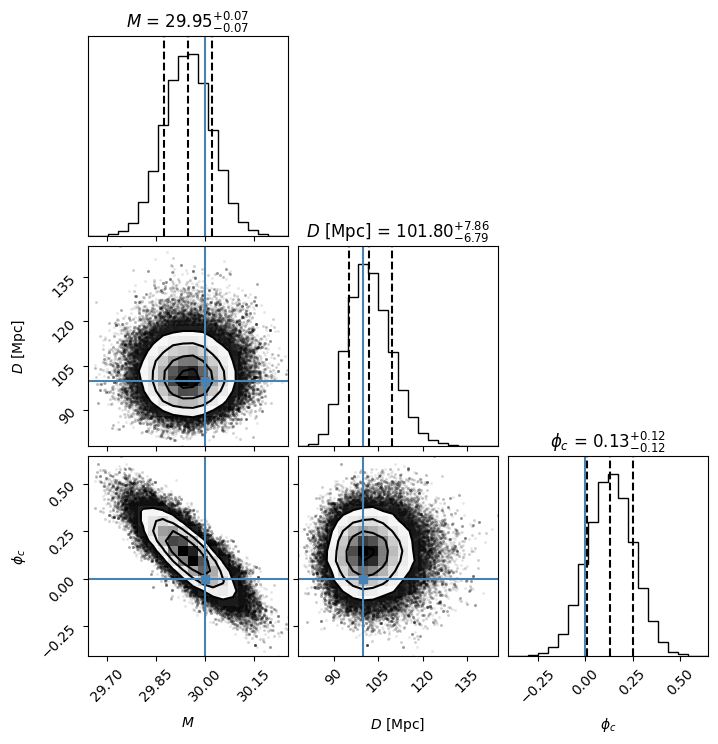

In [33]:
# Corner plot for 3 parameters
corner.corner(flat3,
              labels=['$M$', '$D$ [Mpc]', '$\\phi_c$'],
              truths=[Mc_true, D_true, phic_true],
              quantiles=[0.16, 0.5, 0.84],
              show_titles=True)
plt.show()

## Part XIV – Mini Research Project

Now it's your turn. Investigate the following by modifying the code above. Each question connects to something specific you've already seen in this notebook — use that as your starting point.

1. **How does the Fisher uncertainty scale with SNR?**
   Run `fisher_matrix()` for several values of `sigma` (try 5-6 values spanning the range from Part III's high-SNR case to Part XII's low-SNR case) and plot $\Delta M$ vs. $1/\sigma$. *Hint: Fisher theory predicts this should be close to a straight line — is it?*

2. **When does Fisher agree with the Bayesian posterior?**
   Sweep `sigma` between the high-SNR (Part III) and low-SNR (Part XII) values. At each one, run the MCMC and check what fraction of posterior samples fall inside the 1-sigma Fisher ellipse (a perfect Gaussian would give ~68%). At what SNR does this fraction start dropping noticeably below 68%?

3. **At what SNR does the Fisher ellipse start to visibly fail?**
   Same sweep as above — this time look at the *skewness* of the posterior (Part XII showed you how to compute it) as a function of SNR, rather than just eyeballing the plots.

4. **Which parameters are most strongly correlated?**
   Use the 3-parameter Fisher matrix and corner plot from Part XIII. Which pair of parameters has the largest correlation coefficient, and can you explain *why* physically (which term in the waveform do they both affect)?

5. **How do priors influence the posterior?**
   Try a log-uniform prior on distance (`log_prior` returns `-np.log(D)` instead of `0.0` within bounds — this reflects a uniform-in-volume prior, standard in real GW analyses) and a narrower mass prior (e.g. $[28, 32]$ instead of $[10, 50]$). How much does each change the posterior at high SNR? At low SNR?

6. **How does increasing the observation bandwidth improve parameter estimation?**
   Change `f = np.linspace(10, 2000, 4000)` and see how the Fisher uncertainties shrink. **Important:** if you change `f`, you must also re-run Part III (`signal_true`, `noise`, `data`) — they all depend on the length of `f`, and forgetting this is exactly the stale-variable bug we hit back in Part X. Treat it as practice catching that class of bug.

### Bonus: a debugging checklist, from real bugs we hit building this notebook

Every one of these was a genuine issue we found while building this tutorial, not a hypothetical:

- **Check units before trusting a result** (Part VI) — a missing unit conversion made two parameters look perfectly degenerate when they weren't.
- **Scale MCMC initial positions to each parameter's real uncertainty**, not one arbitrary number for all of them (Parts VIII, XII, XIII).
- **Sanity-check `log_posterior(theta_true)`** before running an expensive MCMC — it should be close to $-\tfrac{1}{2}\times(\text{number of data points})$ if the model and data actually match (Part X).
- **Re-run every downstream cell after editing an upstream one** — Jupyter/Colab won't do this for you.
- **Match your plot's grid range to the actual spread of your data** — a grid sized for a high-SNR posterior will silently clip a low-SNR one (Part XII).
- **Watch for hard prior boundaries on periodic parameters** like $\phi_c$ — if the true value sits at the edge, the posterior gets artificially truncated (Part XIII).

Pick one of these and deliberately break it in a copy of the notebook, then find and fix your own bug using the diagnostics we built. That's genuinely close to what real research debugging looks like.

## Final Extension: Transition to Real GW Analysis

Once you're comfortable with this toy model, you can replace `waveform()` with a physically realistic inspiral waveform generated by **PyCBC** or a full post-Newtonian approximant. The likelihood, Fisher matrix, and MCMC framework here carry over essentially unchanged. You'll then be using the same logical structure as the parameter estimation pipelines actually used by the LIGO-Virgo-KAGRA collaboration today, particularly [PyCBC Inference](https://pycbc.org/) and [bilby](https://lscsoft.docs.ligo.org/bilby/) — both still the standard, actively maintained tools in the field, and both free and open source.

### Bonus: Animating Fisher's Failure as SNR Decreases

Instead of comparing just two SNR values (Parts VII/X vs. XII), we can precompute the posterior and Fisher ellipse at several SNR levels in between, then animate through them — watching the Fisher ellipse's agreement with the true posterior degrade continuously as the signal gets fainter.

Running a full MCMC at every single animation frame would be far too slow, so the standard approach (and good general practice for any animation of expensive results) is: **compute each frame's data once, store it, then animate over the stored results** rather than recomputing live.

In [34]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Sweep from high SNR (Part III) to low SNR (Part XII), log-spaced
sigma_steps = np.geomspace(2e-3, 0.02, 8)

frames = []
for sig in sigma_steps:
    np.random.seed(123)  # same noise "shape" at every step, just scaled -- isolates the SNR effect
    noise_i = np.random.normal(0, 1, len(f)) * sig
    data_i = signal_true + noise_i

    def log_likelihood_i(theta, data_i=data_i, sig=sig):
        Mc, D = theta
        model = np.real(waveform(f, Mc=Mc, D=D, tc=tc_true, phic=phic_true))
        return -0.5 * np.sum((data_i - model)**2 / sig**2)

    def log_posterior_i(theta, ll=log_likelihood_i):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + ll(theta)

    # Fisher: rescale the already-computed high-SNR Gamma (Part VI), same trick as Part XII
    Cov_i = np.linalg.inv(Gamma * (sigma**2 / sig**2))
    scale_i = np.sqrt(np.diag(Cov_i))

    np.random.seed(7)
    pos_i = theta_true + 0.5 * scale_i * np.random.randn(24, 2)
    sampler_i = emcee.EnsembleSampler(24, 2, log_posterior_i)
    sampler_i.run_mcmc(pos_i, 1500, progress=False)
    flat_i = sampler_i.get_chain(discard=500, flat=True)

    snr_i = np.sqrt(np.sum(signal_true**2) / sig**2)
    frames.append({'sigma': sig, 'snr': snr_i, 'Cov': Cov_i, 'samples': flat_i})
    print(f"Precomputed frame: SNR = {snr_i:.1f}")

print(f"\n{len(frames)} frames ready for animation.")

Precomputed frame: SNR = 14.4
Precomputed frame: SNR = 10.4
Precomputed frame: SNR = 7.5
Precomputed frame: SNR = 5.4
Precomputed frame: SNR = 3.9
Precomputed frame: SNR = 2.8
Precomputed frame: SNR = 2.0
Precomputed frame: SNR = 1.4

8 frames ready for animation.


In [35]:
# Build the animation from the precomputed frames
fig, ax = plt.subplots(figsize=(8, 6))

def draw_frame(i):
    ax.clear()
    fr = frames[i]
    ax.scatter(fr['samples'][:, 0], fr['samples'][:, 1], s=2, alpha=0.3, color='steelblue', label='Posterior samples')
    plot_fisher_ellipse(ax, theta_true, fr['Cov'], nstd=1, edgecolor='red', lw=2, label='1-sigma Fisher')
    plot_fisher_ellipse(ax, theta_true, fr['Cov'], nstd=2, edgecolor='orange', lw=2, label='2-sigma Fisher')
    ax.plot(Mc_true, D_true, marker='*', color='black', markersize=18,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5, label='True value')
    ax.set_xlim(20, 40)
    ax.set_ylim(20, 200)
    ax.set_xlabel('Chirp mass $M$')
    ax.set_ylabel('Distance $D$ [Mpc]')
    ax.set_title(f"SNR = {fr['snr']:.1f}  (frame {i+1}/{len(frames)})")
    ax.legend(loc='upper right')

anim = FuncAnimation(fig, draw_frame, frames=len(frames), interval=800)
plt.close()  # prevents a duplicate static plot from also appearing
HTML(anim.to_jshtml())

### What to watch for

As the animation steps from high to low SNR: the posterior cloud should grow steadily wider (as expected — less information means more uncertainty), but watch specifically whether it grows *symmetrically*, matching the Fisher ellipse's growth, or whether it starts to spill outside the ellipse and skew toward one side. The point where visible spillover begins is the SNR where the Gaussian (Fisher) approximation stops being trustworthy — this gives you a much more precise answer than comparing just two static snapshots.